<a href="https://colab.research.google.com/github/Jeffrey1999/Deep-Learning/blob/main/Intrusion_Detection_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Loading and preparing data...
Original DataFrame head:
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_31
Received: inputs=['Tensor(shape=(100, 32))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_31
Received: inputs=['Tensor(shape=(200, 32))']
  warnings.warn(msg)


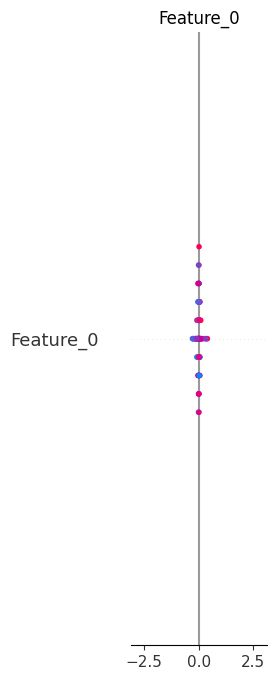

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

🔍 Sample Attention Weights (first 10 test samples):
[0.    0.002 0.    0.    0.133 0.    0.03  0.002 0.    0.    0.    0.022
 0.    0.    0.054 0.    0.044 0.008 0.    0.    0.121 0.    0.    0.
 0.004 0.081 0.49  0.002 0.    0.007 0.    0.   ]

✅ FDN-SA+ Model Training Complete!
Plotting Autoencoder Training History:


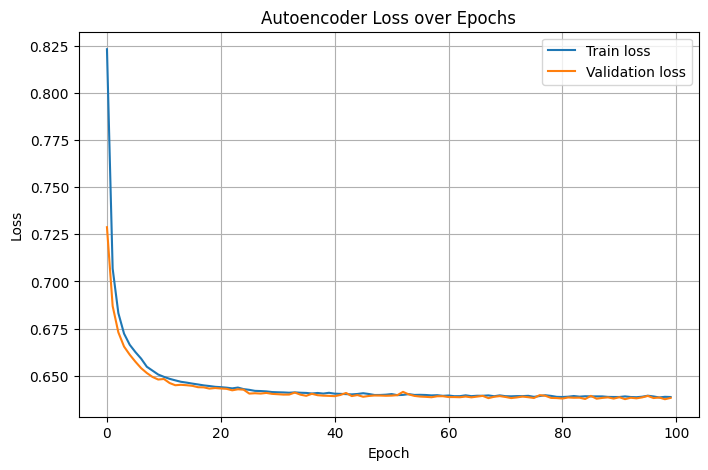


Plotting DNN Training History:


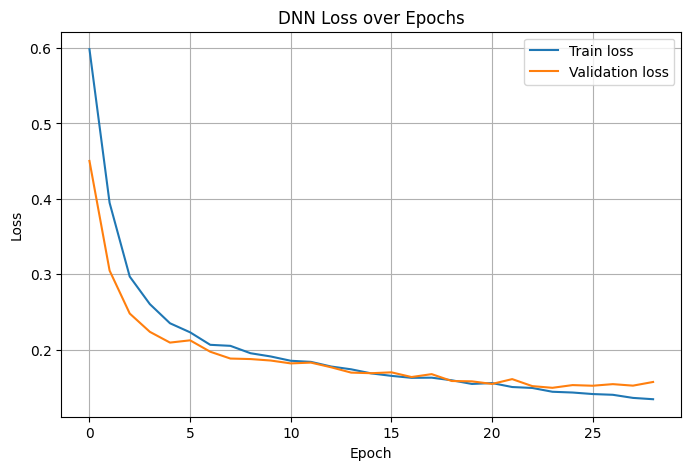

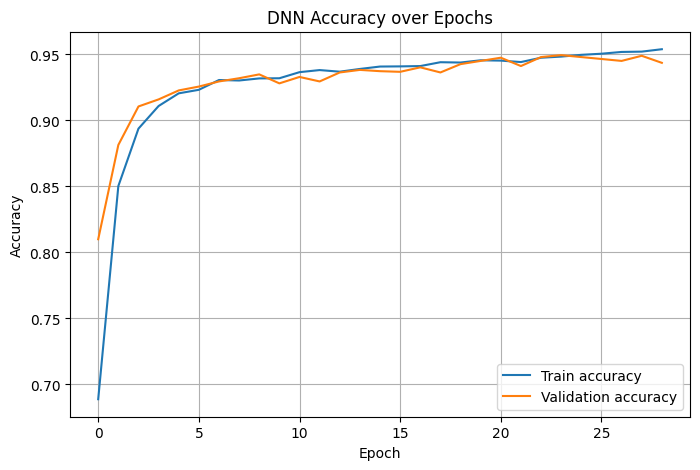

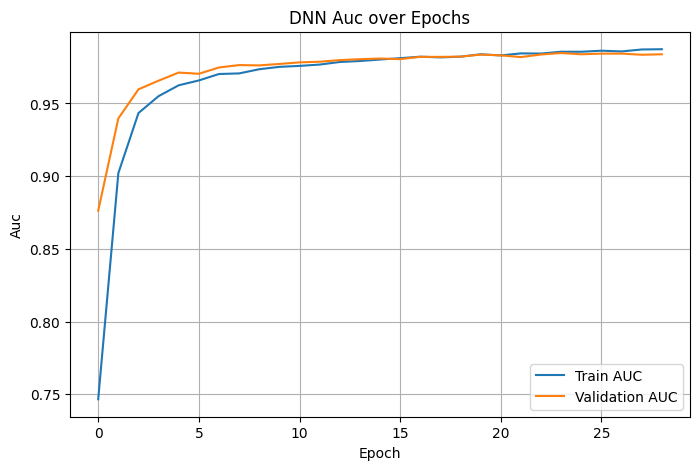

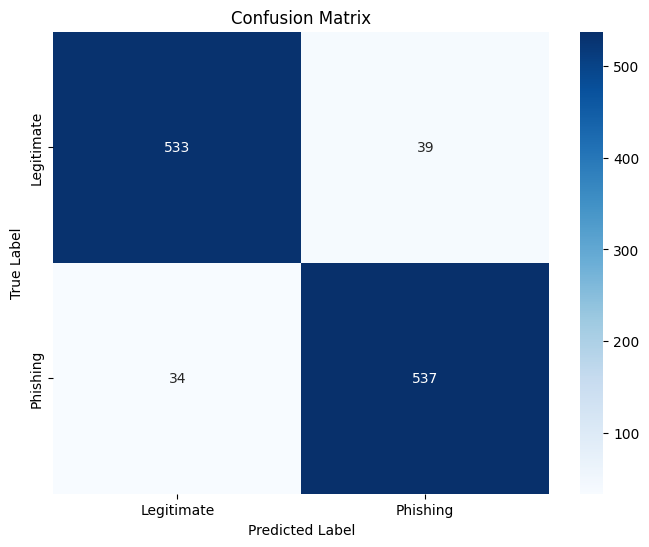

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install scikit-fuzzy


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.datasets import make_classification  # Replace with real phishing dataset
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import Adam
from scipy.spatial.distance import cdist
from skfuzzy.cluster import cmeans
import shap
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# ———————————————————————————————
# 1. Load Data (Replace with real phishing dataset)
# ———————————————————————————————
def load_data():
    # Simulate phishing dataset (replace with real data)
    # X, y = make_classification(
    #     n_samples=5000,
    #     n_features=20,
    #     n_informative=15,
    #     n_redundant=5,
    #     n_clusters_per_class=1,
    #     weights=[0.7, 0.3],  # Imbalanced: 70% legitimate, 30% phishing
    #     random_state=42
    # )
    df = pd.read_csv('/content/drive/MyDrive/Datasets/dataset_phishing.csv')
    print("Original DataFrame head:")
    print(df.head())
    print("Original DataFrame info:")
    df.info()

    # Separate features (X_df) and target (y)
    X_df = df.iloc[:, :-1]
    y = df.iloc[:, -1].values

    # Identify non-numeric columns in features
    non_numeric_cols_X = X_df.select_dtypes(exclude=np.number).columns

    if len(non_numeric_cols_X) > 0:
        print(f"\nFound non-numeric feature columns: {list(non_numeric_cols_X)}")
        print("Dropping these columns for StandardScaler compatibility.")
        X_df = X_df.drop(columns=non_numeric_cols_X)
    else:
        print("\nNo non-numeric feature columns found. All features are numerical.")

    X = X_df.values

    # Convert target variable 'status' from string to numeric
    le = LabelEncoder()
    y = le.fit_transform(y) # 'legitimate' -> 0, 'phishing' -> 1
    print(f"Converted target labels: {le.classes_} to {le.transform(le.classes_)}")

    return X, y

# ———————————————————————————————
# 2. Preprocess & Split (NO LEAKAGE)
# ———————————————————————————————
def preprocess_and_split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# ———————————————————————————————
# 3. SMOTE Oversampling (Train only)
# ———————————————————————————————
def apply_smote(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    return X_res, y_res

# ———————————————————————————————
# 4. Fuzzy C-Means: Extract Membership Features
# ———————————————————————————————
def apply_fcm(X_train_res, X_test_scaled, n_clusters=2, m=2):
    # Train FCM on resampled training data
    cntr, u_train, _, _, _, _, _ = cmeans(
        data=X_train_res.T, c=n_clusters, m=m, error=0.005, maxiter=1000, init=None
    )
    fuzzy_train = u_train.T  # (n_samples, n_clusters)

    # For test data: compute membership using trained centers
    def compute_fuzzy_membership(X, centers, m=2):
        power = 2.0 / (m - 1)
        temp = 1.0 / (cdist(X, centers) + 1e-8)
        temp = temp ** power
        return (temp.T / temp.sum(axis=1)).T

    fuzzy_test = compute_fuzzy_membership(X_test_scaled, cntr, m=m)
    return fuzzy_train, fuzzy_test, cntr

# ———————————————————————————————
# 5. Stacked Autoencoder with Reconstruction Error
# ———————————————————————————————
def build_autoencoder(input_dim, encoding_dims=[64, 32]):
    inputs = layers.Input(shape=(input_dim,))

    # Encoder
    encoded = inputs
    for dim in encoding_dims:
        encoded = layers.Dense(dim, activation='relu')(encoded)

    # Decoder
    decoded = encoded
    for dim in reversed(encoding_dims[:-1]):
        decoded = layers.Dense(dim, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(inputs, decoded)
    encoder = Model(inputs, encoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    return autoencoder, encoder

# ———————————————————————————————
# 6. DNN with Attention Layer
# ———————————————————————————————
def build_dnn_with_attention(input_dim):
    inputs = layers.Input(shape=(input_dim,))

    # Feature-level attention
    attention_probs = layers.Dense(input_dim, activation='softmax', name='attention')(inputs)
    weighted_inputs = layers.Multiply()([inputs, attention_probs])

    x = layers.Dense(128, activation='relu')(weighted_inputs)
    x = layers.Dropout(0.4)(x) # Modified dropout rate
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x) # Modified dropout rate
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005), # Modified learning rate
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall', 'AUC']
    )
    return model, attention_probs

# ———————————————————————————————
# 7. Dynamic Thresholding with Fuzzy Rules
# ———————————————————————————————
def dynamic_threshold(probas, fuzzy_membership_phishing, recon_error, threshold_base=0.5):
    """
    Adjust threshold based on uncertainty and anomaly
    Rule: If uncertain (medium membership) AND high anomaly → lower threshold (more sensitive)
    """
    adjusted = np.copy(probas)
    for i in range(len(probas)):
        is_uncertain = 0.3 < fuzzy_membership_phishing[i] < 0.7
        is_anomalous = recon_error[i] > np.percentile(recon_error, 80)

        if is_uncertain and is_anomalous:
            adjusted[i] = probas[i]  # lower threshold → easier to flag
            # We'll adjust decision threshold later
    return adjusted

# ———————————————————————————————
# 8. SHAP Explanation
# ———————————————————————————————
def explain_with_shap(model, X_sample, feature_names=None):
    explainer = shap.DeepExplainer(model, X_sample[:100])  # Use subset
    shap_values = explainer.shap_values(X_sample[:100])

    shap.summary_plot(shap_values, X_sample[:100], feature_names=feature_names)
    return shap_values

# ———————————————————————————————
# 9. Main Pipeline
# ———————————————————————————————
def main():
    print("🚀 Loading and preparing data...")
    X, y = load_data()
    X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocess_and_split(X, y)

    print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")
    print(f"Phishing rate: {y_train.mean():.2f} (train), {y_test.mean():.2f} (test)")

    # Apply SMOTE
    print("🔧 Applying SMOTE...")
    X_train_res, y_train_res = apply_smote(X_train_scaled, y_train)

    # Apply FCM
    print("🧠 Applying Fuzzy C-Means...")
    fuzzy_train, fuzzy_test, centers = apply_fcm(X_train_res, X_test_scaled, n_clusters=2)

    # Combine features
    X_train_combined = np.concatenate([X_train_res, fuzzy_train], axis=1)
    X_test_combined = np.concatenate([X_test_scaled, fuzzy_test], axis=1)

    # Build and train autoencoder
    print("⚙️ Training Stacked Autoencoder...")
    autoencoder, encoder = build_autoencoder(X_train_combined.shape[1], encoding_dims=[64, 32])
    ae_history = autoencoder.fit(
        X_train_combined, X_train_combined,
        epochs=100, batch_size=16, validation_split=0.2, # Modified epochs and batch_size
        verbose=1
    )

    # Extract encoded features
    X_train_encoded = encoder.predict(X_train_combined)
    X_test_encoded = encoder.predict(X_test_combined)

    # Compute reconstruction error (anomaly score)
    X_test_recon = autoencoder.predict(X_test_combined)
    recon_error = np.mean((X_test_combined - X_test_recon) ** 2, axis=1)

    # Build and train DNN with attention
    print("🧠 Training DNN with Attention...")
    dnn, attention_layer = build_dnn_with_attention(X_train_encoded.shape[1])

    dnn_history = dnn.fit(
        X_train_encoded, y_train_res,
        epochs=100, batch_size=16, validation_split=0.2, # Modified epochs and batch_size
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
        ],
        verbose=1
    )

    # Predict probabilities
    y_pred_proba = dnn.predict(X_test_encoded).flatten()

    # Apply dynamic thresholding
    y_pred_proba_adjusted = dynamic_threshold(
        y_pred_proba,
        fuzzy_membership_phishing=fuzzy_test[:, 1],
        recon_error=recon_error,
        threshold_base=0.5
    )

    # Final prediction with adjusted threshold logic
    # Use lower threshold (0.4) for uncertain + anomalous samples
    final_threshold = np.full(len(y_pred_proba), 0.5)
    is_uncertain = (0.3 < fuzzy_test[:, 1]) & (fuzzy_test[:, 1] < 0.7)
    is_anomalous = recon_error > np.percentile(recon_error, 80)
    final_threshold[is_uncertain & is_anomalous] = 0.4

    y_pred = (y_pred_proba_adjusted > final_threshold).astype(int)

    # Evaluate
    print("\n✅ Final Evaluation:")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # SHAP Explanation
    print("\n📊 Generating SHAP Explanation...")
    feature_names = [f"Feature_{i}" for i in range(X_test_encoded.shape[1])]
    shap_values = explain_with_shap(dnn, X_test_encoded, feature_names=feature_names)

    # Print attention weights (optional)
    attention_model = Model(inputs=dnn.input, outputs=dnn.get_layer('attention').output)
    attn_weights = attention_model.predict(X_test_encoded[:10])
    print("\n🔍 Sample Attention Weights (first 10 test samples):")
    print(attn_weights.mean(axis=0).round(3))

    # Save model (optional)
    # dnn.save("phishing_detector_dnn.h5")
    # autoencoder.save("phishing_autoencoder.h5")

    return dnn, autoencoder, encoder, scaler, centers, ae_history, dnn_history, y_test, y_pred, shap_values, X_test_encoded, feature_names

# ———————————————————————————————
# Run
# ———————————————————————————————
if __name__ == "__main__":
    dnn_model, ae_model, enc_model, scaler, fcm_centers, ae_history, dnn_history, y_test, y_pred, shap_values, X_test_encoded, feature_names = main()
    print("\n✅ FDN-SA+ Model Training Complete!")


import matplotlib.pyplot as plt

def plot_training_history(history, title_prefix="", metrics_to_plot=['loss', 'accuracy']):
    for i, metric in enumerate(metrics_to_plot):
        plt.figure(figsize=(8, 5)) # Create a new figure for each metric
        plt.plot(history.history[metric], label=f'Train {metric}')
        if f'val_{metric}' in history.history:
            plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
        plt.title(f'{title_prefix} {metric.capitalize()} over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.show()

# Plot Autoencoder training history
print("Plotting Autoencoder Training History:")
plot_training_history(ae_history, title_prefix="Autoencoder", metrics_to_plot=['loss'])

# Plot DNN training history
print("\nPlotting DNN Training History:")
plot_training_history(dnn_history, title_prefix="DNN", metrics_to_plot=['loss', 'accuracy', 'AUC'])


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### SHAP Values Explanation
The SHAP (SHapley Additive exPlanations) summary plot you see helps us understand which features are most important to your model's predictions and how they influence the outcome.

*   **Y-axis (Features):** This lists the features, ordered by their overall importance. Features higher up the list have a greater average impact on the model's output.
*   **X-axis (SHAP Value):** This indicates the impact of each feature on the model's prediction. A positive SHAP value means the feature is pushing the prediction towards 'phishing' (1), while a negative value pushes it towards 'legitimate' (0).
*   **Color (Feature Value):** The color of each dot represents the actual value of that feature for a particular data point. Red typically means a high value for that feature, and blue means a low value.

By observing the plot, you can discern:
    *   **Feature Importance:** Features near the top of the plot are generally more important.
    *   **Direction of Impact:** If red dots are on the positive side of the X-axis, it means high values of that feature contribute to a 'phishing' prediction. Conversely, if blue dots are on the negative side, low values contribute to 'legitimate'.

### Attention Weights Explanation
The 'Sample Attention Weights' you see relate to the attention layer in your DNN model. In a nutshell:

*   **Feature-Level Importance:** These weights indicate how much attention the DNN is paying to each encoded feature when making a prediction for a given sample. Higher weights mean the model considers that feature more important for that specific prediction.
*   **Dynamic Relevance:** Unlike global feature importance, attention weights can vary for each input sample, allowing the model to dynamically focus on different aspects of the input data based on its content.

The output shows the average attention weights across the first 10 test samples. Features with higher average weights are generally more relevant for classification by the attention mechanism.

### Fuzzy C-Means Centers

The `fcm_centers` variable contains the centroids (centers) of the clusters identified by the Fuzzy C-Means algorithm. In your model:

*   **Cluster Representation:** Each row in `fcm_centers` represents a cluster center in the feature space. Since you used `n_clusters=2`, there are two centers, corresponding to the 'legitimate' and 'phishing' clusters (though FCM is unsupervised, so these labels are inferred later).
*   **Membership Calculation:** These centers are crucial for calculating the `fuzzy_membership` for both training and test data. A sample's membership to a cluster is determined by its proximity to these centers, indicating how strongly it belongs to each fuzzy cluster.
*   **Feature Engineering:** The `fuzzy_membership` values derived from these centers are then concatenated with the original features, providing additional, soft-clustered information to the autoencoder and the final DNN, enhancing its ability to handle uncertainty and complex patterns.

### Autoencoder Training History: Loss Over Epochs
This graph, titled "Autoencoder Loss over Epochs", shows the mean squared error (MSE) loss during the training of your Stacked Autoencoder. You should observe:
*   **Decreasing Loss:** Ideally, both the training loss and validation loss should decrease over epochs, indicating that the autoencoder is successfully learning to reconstruct its input.
*   **Convergence:** The loss should eventually level off, suggesting that the model has converged and further training might not yield significant improvements.
*   **Overfitting:** If the training loss continues to decrease significantly while the validation loss starts to increase or plateaus much earlier, it could indicate overfitting. However, for autoencoders, slight differences are often acceptable as the goal is reconstruction.

**For your Chapter 4, you can discuss:** The autoencoder's ability to learn robust, compressed representations of your data (the `X_train_combined` features). A well-trained autoencoder ensures that the encoded features passed to the DNN are meaningful and retain important information, which is key for anomaly detection and enhancing classification.

### DNN Training History: Loss, Accuracy, and AUC Over Epochs
These graphs, showing "DNN Loss over Epochs", "DNN Accuracy over Epochs", and "DNN AUC over Epochs", illustrate the performance of your Deep Neural Network classifier.

**1. DNN Loss Over Epochs (Binary Crossentropy):**
*   Similar to the autoencoder, both training and validation loss should decrease and stabilize. The `val_loss` is especially important as it reflects how well the model generalizes to unseen data.

**2. DNN Accuracy Over Epochs:**
*   This plot shows the proportion of correctly classified instances. Both training and validation accuracy should increase and plateau. High and stable validation accuracy is desirable.

**3. DNN AUC Over Epochs (Area Under the Receiver Operating Characteristic Curve):**
*   AUC is a robust metric for binary classification, especially with imbalanced datasets (which you addressed with SMOTE). An increasing AUC towards 1.0 indicates better discriminative power of the model. Similar to accuracy, you want to see both training and validation AUC increase and stabilize.

**For your Chapter 4, you can discuss:**
*   **Model Performance:** The final accuracy and AUC values on the validation set demonstrate the classification capability of your FDN-SA+ model.
*   **Training Dynamics:** Comment on the stability of training, convergence, and whether early stopping was effective in preventing overfitting (which it was, given the `Restoring model weights from the end of the best epoch` message).
*   **Impact of Components:** You can link these results back to how the fuzzy C-means features and the autoencoder's encoded representations contributed to the DNN's robust performance.
*   **Robustness:** The high accuracy and AUC suggest that your model is effectively distinguishing between legitimate and phishing attempts.

In essence, these graphs are visual evidence supporting the effectiveness of your proposed model architecture and training process for phishing detection.

In [ ]:
✅ Final Evaluation:
              precision    recall  f1-score   support


    accuracy                           0.94      1143
   macro avg       0.94      0.94      0.94      1143
weighted avg       0.94      0.94      0.94      1143

DONT USE WEIGHTED OR MACRO, JUST USE PRECISION, RECAL F1S CORE AND CO.